# 01. Baseline: признаки только из answer

Первый эксперимент: обучаем модели только на статистических признаках, извлеченных из поля `answer` исходного файла `data.csv`. Признаки описания и изображения здесь не используются.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## Загрузка данных

In [2]:
DATA_PATH = Path("../data.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,id,answer,description,date_posted,img_url,started,solved,users_with_hints,total_hints,solve_rate,hint_usage,avg_hints,difficulty
0,1,брауни,Коричневая английская Е (читается как и) = Bro...,2025-06-01,/daily-rebuses/1_v1.jpg,454,219,110,179,0.4824,0.2423,0.3943,0.4303
1,2,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,2025-06-02,/daily-rebuses/2.jpg,339,162,65,90,0.4779,0.1917,0.2655,0.4010
2,3,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,2025-06-03,/daily-rebuses/3_v1.jpg,276,134,38,56,0.4855,0.1377,0.2029,0.3736
3,4,подоконник,Под О Конь и К,2025-06-04,/daily-rebuses/4.jpg,255,183,19,28,0.7176,0.0745,0.1098,0.2045
4,5,редактор,Красный актер = Red Actor,2025-06-05,/daily-rebuses/5_v1.jpg,311,200,96,158,0.6431,0.3087,0.5080,0.3675


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                327 non-null    int64  
 1   answer            327 non-null    object 
 2   description       327 non-null    object 
 3   date_posted       327 non-null    object 
 4   img_url           327 non-null    object 
 5   started           327 non-null    int64  
 6   solved            327 non-null    int64  
 7   users_with_hints  327 non-null    int64  
 8   total_hints       327 non-null    int64  
 9   solve_rate        327 non-null    float64
 10  hint_usage        327 non-null    float64
 11  avg_hints         327 non-null    float64
 12  difficulty        327 non-null    float64
dtypes: float64(4), int64(5), object(4)
memory usage: 33.3+ KB


## Извлечение текстовых признаков

Если в ответе несколько вариантов через `|`, признаки считаем только по первому варианту.

In [4]:
VOWELS = set("аеёиоуыэюя")
RARE_LETTERS = set("фщъёцэ")
def extract_answer_features(answer):
    if pd.isna(answer):
        answer = ""

    text = str(answer).lower().strip()
    variants = [part.strip() for part in text.split("|") if part.strip()]
    primary_answer = variants[0] if variants else ""
    compact = primary_answer.replace(" ", "")
    words = [word for word in primary_answer.split() if word]

    letters = [char for char in compact if char.isalpha()]
    cyrillic_letters = [char for char in letters if "а" <= char <= "я" or char == "ё"]
    latin_letters = [char for char in letters if "a" <= char <= "z"]

    len_chars = len(compact)
    vowel_count = sum(char in VOWELS for char in compact)
    consonant_count = sum(char.isalpha() and char not in VOWELS for char in compact)
    rare_count = sum(char in RARE_LETTERS for char in compact)
    unique_chars = len(set(compact))

    return pd.Series(
        {
            "len_chars": len_chars,
            "len_words": len(words),
            "avg_word_len": len_chars / len(words) if words else 0.0,
            "vowel_count": vowel_count,
            "consonant_count": consonant_count,
            "rare_count": rare_count,
            "unique_chars": unique_chars,
            "vowel_ratio": vowel_count / len_chars if len_chars else 0.0,
            "rare_ratio": rare_count / len_chars if len_chars else 0.0,
            "unique_ratio": unique_chars / len_chars if len_chars else 0.0,
            "cyrillic_ratio": len(cyrillic_letters) / len(letters) if letters else 0.0,
            "latin_ratio": len(latin_letters) / len(letters) if letters else 0.0,
            "has_dash": int("-" in text),
            "has_digits": int(any(char.isdigit() for char in primary_answer)),
        }
    )


text_features = df["answer"].apply(extract_answer_features)
text_features.head()

,len_chars,len_words,avg_word_len,vowel_count,consonant_count,rare_count,unique_chars,vowel_ratio,rare_ratio,unique_ratio,cyrillic_ratio,latin_ratio,has_dash,has_digits
0,6.0,1.0,6.0,3.0,3.0,0.0,6.0,0.500000,0.0,1.000,1.0,0.0,0.0,0.0
1,16.0,2.0,8.0,0.0,16.0,0.0,6.0,0.000000,0.0,0.375,0.0,1.0,0.0,0.0
2,6.0,1.0,6.0,2.0,4.0,0.0,6.0,0.333333,0.0,1.000,1.0,0.0,0.0,0.0
3,10.0,1.0,10.0,4.0,6.0,0.0,6.0,0.400000,0.0,0.600,1.0,0.0,0.0,0.0
4,8.0,1.0,8.0,3.0,5.0,0.0,7.0,0.375000,0.0,0.875,1.0,0.0,0.0,0.0


In [5]:
dataset = pd.concat([df[["answer", "difficulty"]], text_features], axis=1)
dataset.head()

,answer,difficulty,len_chars,len_words,avg_word_len,vowel_count,consonant_count,rare_count,unique_chars,vowel_ratio,rare_ratio,unique_ratio,cyrillic_ratio,latin_ratio,has_dash,has_digits
0,брауни,0.4303,6.0,1.0,6.0,3.0,3.0,0.0,6.0,0.500000,0.0,1.000,1.0,0.0,0.0,0.0
1,tralalelo tralala|тралалело тралала|тралалеро ...,0.4010,16.0,2.0,8.0,0.0,16.0,0.0,6.0,0.000000,0.0,0.375,0.0,1.0,0.0,0.0
2,свитер|свита,0.3736,6.0,1.0,6.0,2.0,4.0,0.0,6.0,0.333333,0.0,1.000,1.0,0.0,0.0,0.0
3,подоконник,0.2045,10.0,1.0,10.0,4.0,6.0,0.0,6.0,0.400000,0.0,0.600,1.0,0.0,0.0,0.0
4,редактор,0.3675,8.0,1.0,8.0,3.0,5.0,0.0,7.0,0.375000,0.0,0.875,1.0,0.0,0.0,0.0


## Обучение моделей

In [6]:
X = text_features
y = df["difficulty"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train.shape, X_test.shape

((261, 14), (66, 14))

In [7]:
RANDOM_STATE = 42


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def scaled_model(model):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", model),
        ]
    )


models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "linear_regression": scaled_model(LinearRegression()),
    "ridge": scaled_model(Ridge(alpha=1.0)),
    "lasso": scaled_model(Lasso(alpha=0.001, max_iter=10_000, random_state=RANDOM_STATE)),
    "elastic_net": scaled_model(
        ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000, random_state=RANDOM_STATE)
    ),
    "svr_rbf": scaled_model(SVR(kernel="rbf", C=1.0, epsilon=0.05)),
    "knn_5": scaled_model(KNeighborsRegressor(n_neighbors=5, weights="distance")),
    "random_forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
}


def regression_metrics(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
    }


def evaluate_holdout(models, X_train, X_test, y_train, y_test):
    rows = []
    fitted_models = {}

    for name, model in models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)
        y_pred = fitted_model.predict(X_test)

        rows.append({"model": name, **regression_metrics(y_test, y_pred)})
        fitted_models[name] = fitted_model

    metrics = pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)
    return metrics, fitted_models


holdout_metrics, fitted_models = evaluate_holdout(models, X_train, X_test, y_train, y_test)
holdout_metrics

,model,r2,mae
0,gradient_boosting,0.049792,0.076881
1,random_forest,0.033176,0.077897
2,extra_trees,0.020422,0.078491
3,dummy_mean,-0.003498,0.079346
4,svr_rbf,-0.074204,0.080089
5,lasso,0.014880,0.080906
6,elastic_net,0.011410,0.081250
7,ridge,0.009729,0.081592
8,linear_regression,-0.005384,0.082151
9,knn_5,-0.308981,0.091926


## Кросс-валидация

На маленьком датасете один train/test split может сильно шуметь, поэтому дополнительно смотрим 5-fold CV.

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": make_scorer(rmse_score, greater_is_better=False),
}

cv_rows = []

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    cv_rows.append(
        {
            "model": name,
            "r2_mean": scores["test_r2"].mean(),
            "r2_std": scores["test_r2"].std(),
            "mae_mean": -scores["test_mae"].mean(),
            "mae_std": scores["test_mae"].std(),
            "rmse_mean": -scores["test_rmse"].mean(),
            "rmse_std": scores["test_rmse"].std(),
        }
    )

cv_metrics = pd.DataFrame(cv_rows).sort_values("mae_mean").reset_index(drop=True)
cv_metrics

,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,lasso,0.008216,0.051293,0.088064,0.004652,0.104456,0.004213
1,extra_trees,-0.005496,0.050952,0.088148,0.005699,0.105196,0.004595
2,elastic_net,0.004060,0.051749,0.088239,0.004506,0.104675,0.004248
3,gradient_boosting,-0.020505,0.073660,0.088247,0.006893,0.105973,0.005921
4,dummy_mean,-0.024909,0.026177,0.088526,0.004783,0.106227,0.003859
5,ridge,-0.006322,0.049314,0.088542,0.004164,0.105232,0.004356
6,linear_regression,-0.011963,0.051273,0.088626,0.004106,0.105517,0.004248
7,random_forest,-0.025728,0.058485,0.089029,0.006377,0.106257,0.005171
8,svr_rbf,-0.142391,0.077145,0.091971,0.006699,0.112128,0.005987
9,knn_5,-0.341173,0.130530,0.099489,0.007242,0.121381,0.007403


## Сравнение holdout и cross-validation

In [9]:
summary = holdout_metrics.merge(
    cv_metrics,
    on="model",
    how="left",
)

summary[
    [
        "model",
        "mae",
        "r2",
        "mae_mean",
        "mae_std",
        "rmse_mean",
        "r2_mean",
        "r2_std",
    ]
].sort_values("mae_mean")

,model,mae,r2,mae_mean,mae_std,rmse_mean,r2_mean,r2_std
5,lasso,0.080906,0.014880,0.088064,0.004652,0.104456,0.008216,0.051293
2,extra_trees,0.078491,0.020422,0.088148,0.005699,0.105196,-0.005496,0.050952
6,elastic_net,0.081250,0.011410,0.088239,0.004506,0.104675,0.004060,0.051749
0,gradient_boosting,0.076881,0.049792,0.088247,0.006893,0.105973,-0.020505,0.073660
3,dummy_mean,0.079346,-0.003498,0.088526,0.004783,0.106227,-0.024909,0.026177
7,ridge,0.081592,0.009729,0.088542,0.004164,0.105232,-0.006322,0.049314
8,linear_regression,0.082151,-0.005384,0.088626,0.004106,0.105517,-0.011963,0.051273
1,random_forest,0.077897,0.033176,0.089029,0.006377,0.106257,-0.025728,0.058485
4,svr_rbf,0.080089,-0.074204,0.091971,0.006699,0.112128,-0.142391,0.077145
9,knn_5,0.091926,-0.308981,0.099489,0.007242,0.121381,-0.341173,0.130530


## Лучшая модель и ошибки на holdout

In [10]:
best_model_name = cv_metrics.iloc[0]["model"]
best_model = fitted_models[best_model_name]
y_pred = best_model.predict(X_test)

print(f"Best model by CV MAE: {best_model_name}")

predictions = pd.DataFrame(
    {
        "answer": df.loc[y_test.index, "answer"],
        "actual_difficulty": y_test,
        "predicted_difficulty": y_pred,
        "absolute_error": np.abs(y_test - y_pred),
    }
).sort_values("absolute_error", ascending=False)

predictions.head(20)

Best model by CV MAE: lasso


,answer,actual_difficulty,predicted_difficulty,absolute_error
322,даль,0.4194,0.173582,0.245818
309,прошлое,0.4189,0.211990,0.206910
7,рампа,0.3712,0.185839,0.185361
324,песок,0.0022,0.187140,0.184940
16,сантехника,0.4230,0.249431,0.173569
291,подошва,0.0424,0.211990,0.169590
275,тролль,0.0465,0.197465,0.150965
94,3 сентября|третье сентября,0.0807,0.223357,0.142657
144,подлива,0.0732,0.213292,0.140092
199,деловая колбаса,0.1274,0.261024,0.133624


## Важность признаков лучшей модели

Permutation importance показывает, насколько ухудшается MAE при случайном перемешивании каждого признака.

In [11]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)

feature_importance = pd.DataFrame(
    {
        "feature": X.columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)

feature_importance

,feature,importance_mean,importance_std
2,avg_word_len,0.002994,0.003265
12,has_dash,0.000025,0.000022
0,len_chars,0.000000,0.000000
7,vowel_ratio,0.000000,0.000000
8,rare_ratio,0.000000,0.000000
9,unique_ratio,0.000000,0.000000
10,cyrillic_ratio,0.000000,0.000000
11,latin_ratio,0.000000,0.000000
13,has_digits,0.000000,0.000000
4,consonant_count,-0.000009,0.000246


## Распределение реальных и предсказанных значений

Сравнение плотности распределения целевой переменной на тестовой выборке.

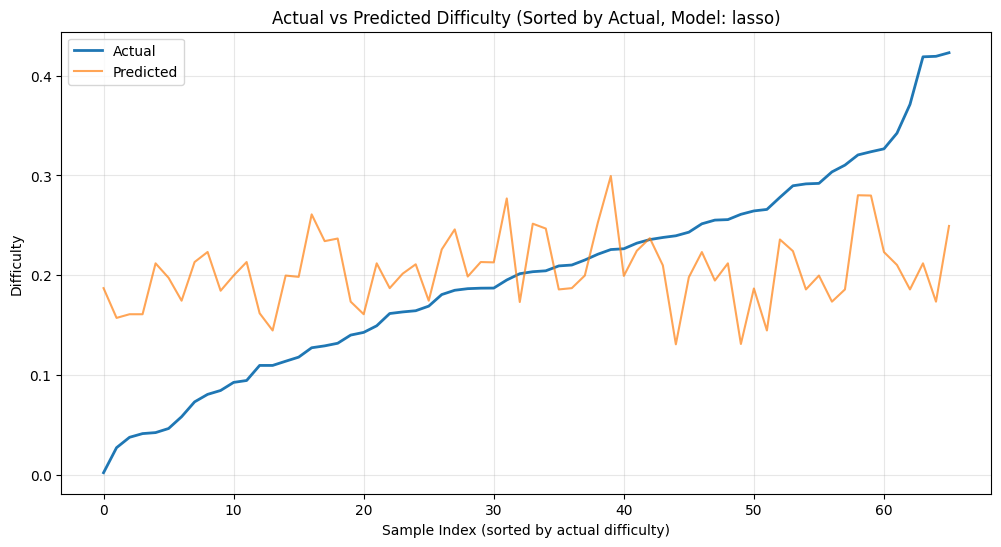

In [12]:
plot_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}).sort_values("Actual").reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(plot_df["Actual"].values, label="Actual", linewidth=2)
plt.plot(plot_df["Predicted"].values, label="Predicted", alpha=0.7)
plt.title(f"Actual vs Predicted Difficulty (Sorted by Actual, Model: {best_model_name})")
plt.xlabel("Sample Index (sorted by actual difficulty)")
plt.ylabel("Difficulty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()